# Zaman Bazlı Analiz

## Amaç:
  1. Tarih bilgisi ile zaman bazlı analiz yapma
  2. Siparilerin dönemsel dağılımını ve zaman içindeki temel örüntüleri incelemek

## Adımlar:
  1. Veri setini yükle
  2. Sipariş tarihini datetime tipine dönüştür
  3. Tarih sütunundan zaman özelliklerini üretmek
  4. Aylara göre sipariş sayısını inceleme
  5. Aylara göre toplam tutarı inceleme
  6. Aylara göre ortalama sipariş tutarı
  7. Haftanın günlerine göre sipariş dağılımı
  8. Haftanın günelerine göre toplam tutar
  9. En yoğun sipariş dönemlerini belirle
  10. Zaman bazlı analiz sonuçlarını görselleştir

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1. Veri setini yükle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.shape

(1186, 22)

In [7]:
# siparis_tarihi datetime tipine çevir
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [11]:
# 3. Tarih  sutunundan zaman özelliklerini türetelim
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()

In [13]:
# 4. aylara göre sipariş sayısı inceleme
aylik_siparis_sayisi = (
    df.groupby("siparis_ayi")
    .size()
    .reset_index(name = "siparis_sayisi")
    .sort_values("siparis_ayi")
)
aylik_siparis_sayisi

,siparis_ayi,siparis_sayisi
0,1,104
1,2,91
2,3,99
3,4,121
4,5,107
5,6,91
6,7,87
7,8,87
8,9,102
9,10,97


In [15]:
# 5. Aylara göre toplam tutar
aylik_toplam_tutar = (
    df.groupby("siparis_ayi")["toplam_tutar"]
    .sum()
    .reset_index(name = "toplam_tutar")
    .sort_values("siparis_ayi")
)
aylik_toplam_tutar

,siparis_ayi,toplam_tutar
0,1,81122.86
1,2,74048.90
2,3,78418.68
3,4,76862.50
4,5,93420.36
5,6,85628.94
6,7,73457.11
7,8,64133.34
8,9,85483.79
9,10,71982.43


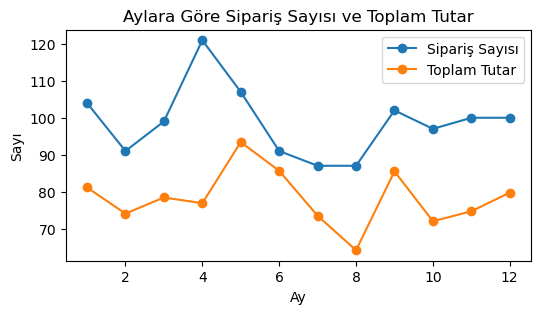

In [17]:
# Siparis sayisi ve toplam tutar arasındaki ilişkiyi anlamak için line plot çizdir
plt.figure(figsize = (6,3))
plt.plot(aylik_siparis_sayisi["siparis_ayi"], aylik_siparis_sayisi["siparis_sayisi"], marker = "o", label = "Sipariş Sayısı")
plt.plot(aylik_toplam_tutar["siparis_ayi"], aylik_toplam_tutar["toplam_tutar"]/1000, marker = "o", label = "Toplam Tutar")
plt.title("Aylara Göre Sipariş Sayısı ve Toplam Tutar")
plt.xlabel("Ay")
plt.ylabel("Sayı")
plt.legend()
plt.show()

In [19]:
# 6. Adım aylara göre toplam sipariş tutarı
aylik_ortalama_tutar = (
    df.groupby("siparis_ayi")["toplam_tutar"]
    .mean()
    .reset_index(name = "ortalama_siparis_tutari")
    .sort_values("siparis_ayi")
)
aylik_ortalama_tutar

,siparis_ayi,ortalama_siparis_tutari
0,1,780.027500
1,2,813.724176
2,3,792.107879
3,4,635.227273
4,5,873.087477
5,6,940.977363
6,7,844.334598
7,8,737.164828
8,9,838.076373
9,10,742.086907


In [21]:
# 7. Haftanın günlerine göre sipariş dağılımı
gun_sirasi = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
gun_siparis_sayisi = (
    df.groupby("haftanin_gunu")
    .size()
    .reindex(gun_sirasi)
    .reset_index(name = "siparis_sayisi")
)
gun_siparis_sayisi

,haftanin_gunu,siparis_sayisi
0,Monday,154
1,Tuesday,183
2,Wednesday,163
3,Thursday,174
4,Friday,163
5,Saturday,186
6,Sunday,163
